# **1) 날짜 데이터 다루기**

**데이터 분석에서 날짜의 역할**
- 날짜 데이터는 시간의 흐름에 따른 변화를 분석할 수 있는 중요한 요소임.
    - ex) 판매 데이터, 주식 가격, 웹사이트 트래픽 등은 모두 시간의 흐름에 따라 변동되며, 이를 분석하는 것은 중요한 비즈니스 의사결정에 필수적임.
- 날짜 데이터를 통해 주간, 월간, 연간 트렌드를 분석하거나 계절성을 파악할 수 있음.
- 비즈니스에서는 과거 데이터를 바탕으로 미래의 수요를 예측하거나, 마케팅 캠페인의 효과를 시간에 따라 측정하는 데 사용됨.

In [15]:
import pandas as pd

In [83]:
df = pd.read_csv('05_kakao_stock(datetime).csv', index_col=0)
df.head()

,종목코드,종목명,날짜,종가,시가,저가,거래량
0,5930,카카오,20230101,61000,60500,60000,15800000
1,5930,카카오,20230102,61200,61000,60800,10500000
2,5930,카카오,20230103,61500,61300,61100,13200000
3,5930,카카오,20230104,61800,61600,61400,12600000
4,5930,카카오,20230105,62000,61800,61600,14200000


In [84]:
# 날짜 데이터 확인
df['날짜']

0      20230101
1      20230102
2      20230103
3      20230104
4      20230105
         ...   
345    20231215
346    20231216
347    20231217
348    20231218
349    20231219
Name: 날짜, Length: 350, dtype: int64

#### **pd.to_datetime: 문자열 데이터를 날짜 형식으로 변환**
- arg: 변환할 데이터, 예를 들어 df['날짜'].
- format: 날짜 형식을 지정하여 처리 속도를 높일 수 있음 (%Y%m%d는 'YYYYMMDD' 형식)
- 날짜를 datetime 형식으로 변환하여 날짜 기반 분석의 기초를 마련함. 이후 주차별, 월별, 요일별 분석을 할 수 있게 됨.

#### **step 1: 날짜를 datetime 형식으로 변환**

In [85]:
# to_datetime() : 문자를 날짜 형식으로 변환

df['날짜'] = pd.to_datetime(df['날짜'], format='%Y%m%d')
df

,종목코드,종목명,날짜,종가,시가,저가,거래량
0,5930,카카오,2023-01-01,61000,60500,60000,15800000
1,5930,카카오,2023-01-02,61200,61000,60800,10500000
2,5930,카카오,2023-01-03,61500,61300,61100,13200000
3,5930,카카오,2023-01-04,61800,61600,61400,12600000
4,5930,카카오,2023-01-05,62000,61800,61600,14200000
...,...,...,...,...,...,...,...
345,5930,카카오,2023-12-15,143500,143400,143300,33200000
346,5930,카카오,2023-12-16,143800,143700,143600,33250000
347,5930,카카오,2023-12-17,144100,144000,143900,33300000
348,5930,카카오,2023-12-18,144400,144300,144200,33350000


#### **step 2: 새로운 열 추가 - 주차별, 월별, 요일별 분석**
- 주차별로 데이터를 그룹화하여 주간 성과를 분석할 수 있음.
- dt.year: 날짜에서 연도 정보를 추출함.
- dt.month: 날짜에서 월 정보를 추출함.
- dt.isocalendar().week: 날짜 데이터에서 ISO 주차 정보를 추출함
- dt.day_name: 날짜에서 요일 정보를 반환함

In [87]:
# 연도 추가 열 생성
df['연도'] = df['날짜'].dt.year
df

,종목코드,종목명,날짜,종가,시가,저가,거래량,연도
0,5930,카카오,2023-01-01,61000,60500,60000,15800000,2023
1,5930,카카오,2023-01-02,61200,61000,60800,10500000,2023
2,5930,카카오,2023-01-03,61500,61300,61100,13200000,2023
3,5930,카카오,2023-01-04,61800,61600,61400,12600000,2023
4,5930,카카오,2023-01-05,62000,61800,61600,14200000,2023
...,...,...,...,...,...,...,...,...
345,5930,카카오,2023-12-15,143500,143400,143300,33200000,2023
346,5930,카카오,2023-12-16,143800,143700,143600,33250000,2023
347,5930,카카오,2023-12-17,144100,144000,143900,33300000,2023
348,5930,카카오,2023-12-18,144400,144300,144200,33350000,2023


In [89]:
# 월 정보 추가
df['월'] = df['날짜'].dt.month
df

,종목코드,종목명,날짜,종가,시가,저가,거래량,연도,월
0,5930,카카오,2023-01-01,61000,60500,60000,15800000,2023,1
1,5930,카카오,2023-01-02,61200,61000,60800,10500000,2023,1
2,5930,카카오,2023-01-03,61500,61300,61100,13200000,2023,1
3,5930,카카오,2023-01-04,61800,61600,61400,12600000,2023,1
4,5930,카카오,2023-01-05,62000,61800,61600,14200000,2023,1
...,...,...,...,...,...,...,...,...,...
345,5930,카카오,2023-12-15,143500,143400,143300,33200000,2023,12
346,5930,카카오,2023-12-16,143800,143700,143600,33250000,2023,12
347,5930,카카오,2023-12-17,144100,144000,143900,33300000,2023,12
348,5930,카카오,2023-12-18,144400,144300,144200,33350000,2023,12


In [91]:
# 주차 정보 추가
df['주차'] = df['날짜'].dt.isocalendar().week
df

,종목코드,종목명,날짜,종가,시가,저가,거래량,연도,월,주차
0,5930,카카오,2023-01-01,61000,60500,60000,15800000,2023,1,52
1,5930,카카오,2023-01-02,61200,61000,60800,10500000,2023,1,1
2,5930,카카오,2023-01-03,61500,61300,61100,13200000,2023,1,1
3,5930,카카오,2023-01-04,61800,61600,61400,12600000,2023,1,1
4,5930,카카오,2023-01-05,62000,61800,61600,14200000,2023,1,1
...,...,...,...,...,...,...,...,...,...,...
345,5930,카카오,2023-12-15,143500,143400,143300,33200000,2023,12,50
346,5930,카카오,2023-12-16,143800,143700,143600,33250000,2023,12,50
347,5930,카카오,2023-12-17,144100,144000,143900,33300000,2023,12,50
348,5930,카카오,2023-12-18,144400,144300,144200,33350000,2023,12,51


In [94]:
# 요일 정보 추가
df['요일'] = df['날짜'].dt.day_name()
df

,종목코드,종목명,날짜,종가,시가,저가,거래량,연도,월,주차,요일
0,5930,카카오,2023-01-01,61000,60500,60000,15800000,2023,1,52,Sunday
1,5930,카카오,2023-01-02,61200,61000,60800,10500000,2023,1,1,Monday
2,5930,카카오,2023-01-03,61500,61300,61100,13200000,2023,1,1,Tuesday
3,5930,카카오,2023-01-04,61800,61600,61400,12600000,2023,1,1,Wednesday
4,5930,카카오,2023-01-05,62000,61800,61600,14200000,2023,1,1,Thursday
...,...,...,...,...,...,...,...,...,...,...,...
345,5930,카카오,2023-12-15,143500,143400,143300,33200000,2023,12,50,Friday
346,5930,카카오,2023-12-16,143800,143700,143600,33250000,2023,12,50,Saturday
347,5930,카카오,2023-12-17,144100,144000,143900,33300000,2023,12,50,Sunday
348,5930,카카오,2023-12-18,144400,144300,144200,33350000,2023,12,51,Monday


#### **step 3: 간단히 시각화 해보기**

In [95]:
import seaborn as sns
import matplotlib as mpl
mpl.rc('font', family = 'Malgun Gothic')

<Axes: xlabel='요일', ylabel='count'>

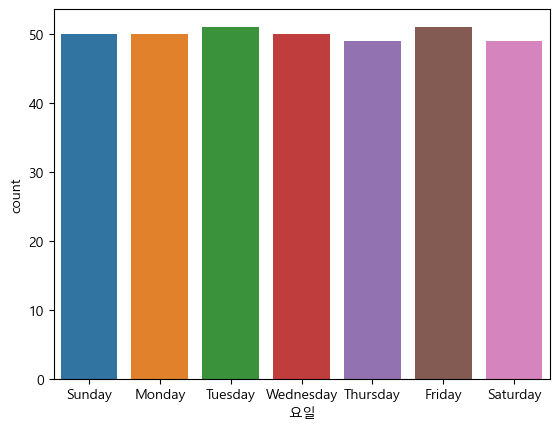

In [102]:
sns.countplot(data=df, x='요일')

<Axes: xlabel='날짜', ylabel='거래량'>

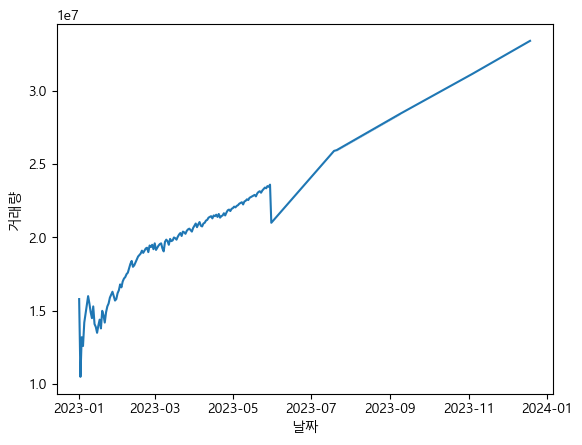

In [100]:
sns.lineplot(data=df, x='날짜', y='거래량')

# **2) 날짜 데이터 다루기 실습**

In [3]:
# 데이터 불러오기
df1 = pd.read_csv('./03_Delivery.csv', encoding='cp949')

In [ ]:
df1.head()

In [108]:
# 날짜 데이터 확인
df1['주문일']

0        20181227
1        20181229
2        20181230
3        20181231
4        20181231
           ...   
46744    20171229
46745    20171229
46746    20171230
46747    20171231
46748    20171231
Name: 주문일, Length: 46749, dtype: int64

### **step 1: 날짜 열 추가, 연도, 월, 주차, 요일 열 추가하기**

In [4]:
# to_date() : 날짜 데이터로 바꾸기
df1['주문일'] = pd.to_datetime(df1['주문일'], format='%Y%m%d')
df1.head()

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일
0,무통장입금,D-20181227-0000648-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,1,PC쇼핑몰,2018-12-27
1,무통장입금,D-20181229-0000119-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,141240,42.0,2,모바일웹,2018-12-29
2,무통장입금,D-20181230-0000100-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,13910,1271.0,1,모바일웹,2018-12-30
3,무통장입금,D-20181231-0000087-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,81600,1085.0,1,모바일웹,2018-12-31
4,무통장입금,D-20181231-0000108-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,94710,1106.0,1,모바일웹,2018-12-31


In [5]:
# 연도 정보 추출하기
df1['연도'] = df1['주문일'].dt.year
df1.head()

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일,연도
0,무통장입금,D-20181227-0000648-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,1,PC쇼핑몰,2018-12-27,2018
1,무통장입금,D-20181229-0000119-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,141240,42.0,2,모바일웹,2018-12-29,2018
2,무통장입금,D-20181230-0000100-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,13910,1271.0,1,모바일웹,2018-12-30,2018
3,무통장입금,D-20181231-0000087-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,81600,1085.0,1,모바일웹,2018-12-31,2018
4,무통장입금,D-20181231-0000108-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,94710,1106.0,1,모바일웹,2018-12-31,2018


In [6]:
# 월 정보 추출하기
df1['월'] = df1['주문일'].dt.month
df1.head()

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일,연도,월
0,무통장입금,D-20181227-0000648-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,1,PC쇼핑몰,2018-12-27,2018,12
1,무통장입금,D-20181229-0000119-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,141240,42.0,2,모바일웹,2018-12-29,2018,12
2,무통장입금,D-20181230-0000100-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,13910,1271.0,1,모바일웹,2018-12-30,2018,12
3,무통장입금,D-20181231-0000087-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,81600,1085.0,1,모바일웹,2018-12-31,2018,12
4,무통장입금,D-20181231-0000108-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,94710,1106.0,1,모바일웹,2018-12-31,2018,12


In [7]:
# 월 정보 추출하기
df1['요일'] = df1['주문일'].dt.day_name()
df1.head()

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일,연도,월,요일
0,무통장입금,D-20181227-0000648-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,1,PC쇼핑몰,2018-12-27,2018,12,Thursday
1,무통장입금,D-20181229-0000119-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,141240,42.0,2,모바일웹,2018-12-29,2018,12,Saturday
2,무통장입금,D-20181230-0000100-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,13910,1271.0,1,모바일웹,2018-12-30,2018,12,Sunday
3,무통장입금,D-20181231-0000087-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,81600,1085.0,1,모바일웹,2018-12-31,2018,12,Monday
4,무통장입금,D-20181231-0000108-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,94710,1106.0,1,모바일웹,2018-12-31,2018,12,Monday


In [8]:
# 월 정보 추출하기
df1['주차'] = df1['주문일'].dt.isocalendar().week
df1.head()

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일,연도,월,요일,주차
0,무통장입금,D-20181227-0000648-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,1,PC쇼핑몰,2018-12-27,2018,12,Thursday,52
1,무통장입금,D-20181229-0000119-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,141240,42.0,2,모바일웹,2018-12-29,2018,12,Saturday,52
2,무통장입금,D-20181230-0000100-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,13910,1271.0,1,모바일웹,2018-12-30,2018,12,Sunday,52
3,무통장입금,D-20181231-0000087-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,81600,1085.0,1,모바일웹,2018-12-31,2018,12,Monday,1
4,무통장입금,D-20181231-0000108-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,94710,1106.0,1,모바일웹,2018-12-31,2018,12,Monday,1


### **step 2: 데이터 트렌드 파악하기**

#### **groupby()** 
- 데이터를 그룹화하여 특정 기준에 따라 데이터를 나눈 후, 그룹별로 다양한 연산

**기본 사용법**
- 그룹화할 열을 기준으로 데이터를 나누고,
- 집계 함수를 사용하여 각 그룹에 대해 연산을 적용
- groupby('기준 열')을 통해 데이터를 기준으로 그룹화.
- 그룹화한 데이터에 대해 sum(), mean(), count() 등 집계 함수를 적용.
- 여러 집계 함수는 agg() 함수로 동시에 적용

**고급 사용법**
- 단일 기준 그룹화: **df.groupby('기준')['열'].함수()**
- 두 가지 기준 그룹화: **df.groupby(['기준1', '기준2'])['열'].함수()**
- 여러 통계 계산: **groupby().agg(['통계1', '통계2'])**
- 열마다 다른 통계 적용: **groupby().agg({'열1': '통계1', '열2': '통계2'})**

#### **한가지 기준으로 1개 열을 집계하기**

In [114]:
# 일자 별 물품 주문량 확인 
df1.groupby('주문일')['수량'].sum()

주문일
2017-01-01     1
2017-01-15     1
2017-01-18     1
2017-01-23     1
2017-02-02     1
              ..
2019-05-31    88
2019-06-01     1
2019-06-02     5
2019-06-04     1
2019-06-19     2
Name: 수량, Length: 807, dtype: int64

In [119]:
# 연도 별 물품 주문량 확인 
df1.groupby('연도')['수량'].sum()

연도
2017     2044
2018    31538
2019    21445
Name: 수량, dtype: int64

In [120]:
# 연도 별 물품 주문량 합계와 평균 
df1.groupby('연도')['수량'].agg(['sum', 'mean'])

,sum,mean
연도,,
2017,2044,1.250918
2018,31538,1.142723
2019,21445,1.224309


In [126]:
# 연도 별 총구매 금액, 평균 구매 금액
df1.groupby('연도')['상품구매금액'].agg(['sum', 'mean'])

,sum,mean
연도,,
2017,108027300,66112.178703
2018,1720813825,62350.586072
2019,1414050260,80729.062571


In [136]:
# 요일별 총 구매 금액
df2 = df1.groupby('요일')['상품구매금액'].agg(['sum', 'mean', 'count'])
df2

,sum,mean,count
요일,,,
Friday,446700690,67021.858965,6665
Monday,689191970,69594.261335,9903
Saturday,132632910,69296.191223,1914
Sunday,174230890,71729.473034,2429
Thursday,597012895,68645.842819,8697
Tuesday,586080424,69738.270347,8404
Wednesday,617041606,70623.967723,8737


#### **여러가지 기준으로 여러가지 열을 집계하기**

In [11]:
# 연도, 월별 수량 합계
df1.groupby(['연도', '월'])['수량'].sum()

연도    월 
2017  1        4
      2       33
      3       49
      4       74
      5      174
      6      167
      7      235
      8      196
      9      231
      10     202
      11     323
      12     356
2018  1      817
      2      652
      3      961
      4     1607
      5     2398
      6     2350
      7     3067
      8     3545
      9     2774
      10    4211
      11    4523
      12    4633
2019  1     4263
      2     3444
      3     4290
      4     5024
      5     4415
      6        9
Name: 수량, dtype: int64

In [14]:
# 연도, 월별 수량의 합계와 평균
df1.groupby(['연도', '월'])['수량'].agg(['sum', 'mean'])

sum      mean
연도   월                 
2017 1      4  1.000000
     2     33  1.222222
     3     49  1.088889
     4     74  1.254237
     5    174  1.216783
     6    167  1.184397
     7    235  1.366279
     8    196  1.264516
     9    231  1.383234
     10   202  1.303226
     11   323  1.187500
     12   356  1.210884
2018 1    817  1.102564
     2    652  1.110733
     3    961  1.130588
     4   1607  1.148678
     5   2398  1.142449
     6   2350  1.161067
     7   3067  1.141847
     8   3545  1.151348
     9   2774  1.180928
     10  4211  1.133208
     11  4523  1.133300
     12  4633  1.136096
2019 1   4263  1.232081
     2   3444  1.174224
     3   4290  1.184428
     4   5024  1.289197
     5   4415  1.227753
     6      9  1.125000

In [17]:
# 연도, 월별 상품구매금액 합계, 수량 평균
df1.groupby(['연도', '월']).agg({'상품구매금액':'sum', '수량':'mean'})

상품구매금액        수량
연도   월                      
2017 1      174200  1.000000
     2     1354715  1.222222
     3     2874175  1.088889
     4     3438890  1.254237
     5     9466180  1.216783
     6     8176710  1.184397
     7    10749480  1.366279
     8     9136970  1.264516
     9    11984480  1.383234
     10   11304120  1.303226
     11   18365570  1.187500
     12   21001810  1.210884
2018 1    44598900  1.102564
     2    32685660  1.110733
     3    47859540  1.130588
     4    88388760  1.148678
     5   134961160  1.142449
     6   132246569  1.161067
     7   164243286  1.141847
     8   192535720  1.151348
     9   159482280  1.180928
     10  227379230  1.133208
     11  243315600  1.133300
     12  253117120  1.136096
2019 1   331938460  1.232081
     2   234876780  1.174224
     3   262786610  1.184428
     4   312055860  1.289197
     5   271851380  1.227753
     6      541170  1.125000

### **step 3간단한 트렌드 파악(시각화)**

In [129]:
import seaborn as sns
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')

In [137]:
df2.reset_index( inplace=True )

<Axes: xlabel='요일', ylabel='sum'>

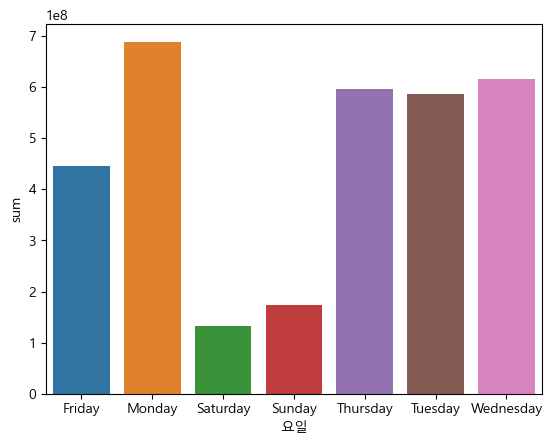

In [138]:
# 요일별 총 판매 금액 트렌드 
sns.barplot(data=df2, x='요일', y='sum')

<Axes: xlabel='요일', ylabel='mean'>

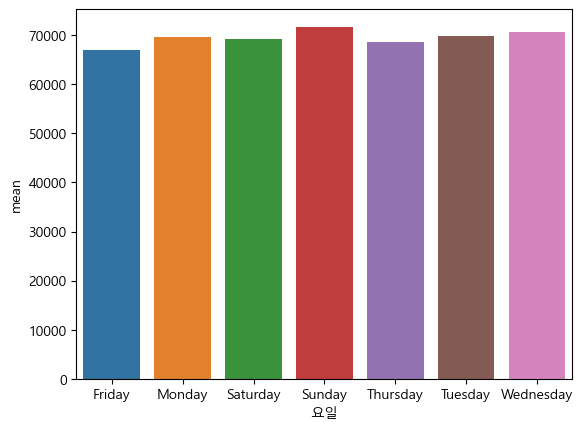

In [140]:
# 요일별 1건당 평균 구매금액
sns.barplot(data=df2, x='요일', y='mean')

<Axes: xlabel='요일', ylabel='count'>

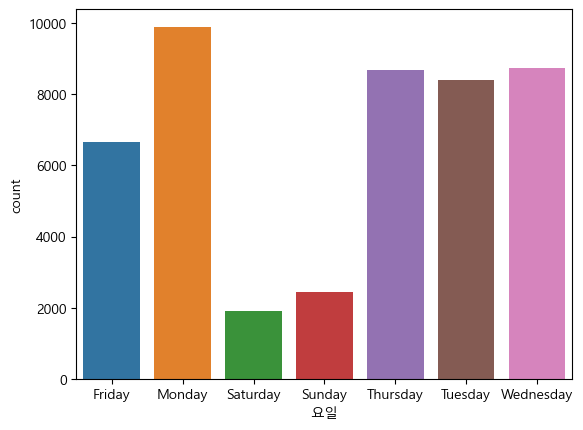

In [141]:
# 요일별 총 주문 건 수
sns.barplot(data=df2, x='요일', y='count')

# **3) 날짜 데이터 다루기 심화**

## **주중, 주말간의 데이터 분석하기**

### **replace() :** 데이터 전처리 과정에서 결측값이나 비정상 값을 대체하는 함수
- DataFrame.replace(to_replace, value)
- to_replace: 대체하고자 하는 값 또는 패턴
- value: 대체할 값

In [20]:
df = pd.read_csv('./pandas_06_replace.csv', index_col = 0)
df

,날짜,종가,거래량
0,2023-01-01,1000,100
1,2023-01-02,2000,200
2,2023-01-03,3000,300
3,2023-01-04,-9999,400


In [145]:
# 오류 값 -9999를 정상 값인 0으로 대체함
df.replace(to_replace = -9999, value=0, inplace=True)

,날짜,종가,거래량
0,2023-01-01,1000,100
1,2023-01-02,2000,200
2,2023-01-03,3000,300
3,2023-01-04,0,400


#### **여러 값 치환**: 한 번에 여러 값을 대체할 수 있음.

In [146]:
# 종가에서 1000은 1500으로, 2000은 2500으로 대체함
df.replace([1000, 2000], [1500, 2500])

,날짜,종가,거래량
0,2023-01-01,1500,100
1,2023-01-02,2500,200
2,2023-01-03,3000,300
3,2023-01-04,-9999,400


#### **딕셔너리** : 사용 열별로 다른 값을 대체할 수 있음.

In [149]:
# 종가에서 -9999는 0으로, 거래량에서 400은 500으로 대체함
df.replace({'종가': {-9999: 0}, '거래량': {400: 500}})

,날짜,종가,거래량
0,2023-01-01,1000,100
1,2023-01-02,2000,200
2,2023-01-03,3000,300
3,2023-01-04,0,500


#### **이전 df1 데이터, 요일을 기준으로 주중, 주말**

In [155]:
df1['요일'].value_counts()

요일
Monday       9903
Wednesday    8737
Thursday     8697
Tuesday      8404
Friday       6665
Sunday       2429
Saturday     1914
Name: count, dtype: int64

In [159]:
# 주말, 주중으로 나눠주기
df1['주중/주말'] = df1['요일'].replace({'Monday' : '주중', 'Tuesday':'주중', 'Wednesday':'주중',\
                   'Thursday':'주중','Friday':'주중', 'Sunday':'주말', 'Saturday':'주말'})

In [161]:
df1.head(3)

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일,연도,월,요일,주차,주중/주말
0,무통장입금,D-20181227-0000648-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,1,PC쇼핑몰,2018-12-27,2018,12,Thursday,52,주중
1,무통장입금,D-20181229-0000119-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,141240,42.0,2,모바일웹,2018-12-29,2018,12,Saturday,52,주말
2,무통장입금,D-20181230-0000100-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,13910,1271.0,1,모바일웹,2018-12-30,2018,12,Sunday,52,주말


In [164]:
# 주중 주말 개수 확인
df1['주중/주말'].value_counts()

주중/주말
주중    42406
주말     4343
Name: count, dtype: int64

In [166]:
# 주중 주말별 총 판매 수량 합계
df1.groupby('주중/주말')['수량'].sum()

주중/주말
주말     5149
주중    49878
Name: 수량, dtype: int64

In [167]:
# 주중 주말별 총 판매금액 합계
df1.groupby('주중/주말')['상품구매금액'].sum()

주중/주말
주말     306863800
주중    2936027585
Name: 상품구매금액, dtype: int64

In [171]:
# 주중 주말별 평균 판매 금액
df1.groupby('주중/주말')['상품구매금액'].mean()

주중/주말
주말    70657.103385
주중    69236.136042
Name: 상품구매금액, dtype: float64

#### **간단하게 시각화 해보기**

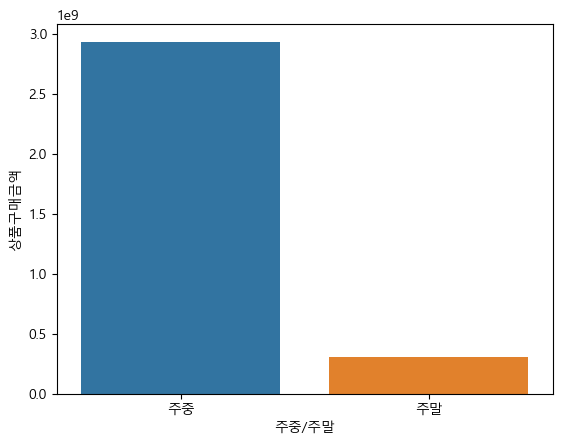

In [177]:
sns.barplot(data=df1, x='주중/주말', y='상품구매금액', errorbar=None,\
            estimator='sum');

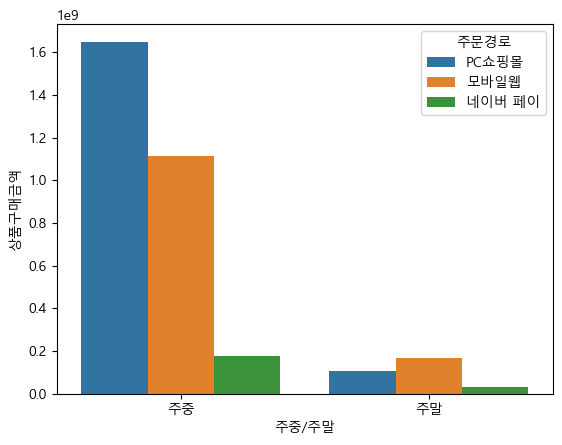

In [176]:
sns.barplot(data=df1, x='주중/주말', y='상품구매금액', errorbar=None,\
            estimator='sum', hue='주문경로');

## **평균 배송기간 계산하기**

### **apply()** : 열 또는 행 단위로 사용자 정의 함수를 적용할 때 사용됨. 
- 데이터프레임의 특정 열이나 행 또는 시리즈에 적용됨.
- DataFrame or Series.apply(func) : 데이터 프레임 또는 시리즈.apply(적용함수)
- 함수는 각 요소(행 또는 열)에 개별적으로 적용됨. 함수는 사용자 정의 함수일 수 있으며, 해당 함수는 각 값에 대해 반복적으로 호출
- 예) 주가 데이터에서 특정 값에 대한 변형을 적용할 수 있음

In [185]:
df = pd.DataFrame({
    'A': [1, 2, 3, 4],
    'B': [10, 20, 30, 40]
})

In [186]:
# 함수 정의: 각 값에 10을 더하는 함수
def 더하기_10(x):
    return x + 10

In [188]:
# apply()로 'A' 열에 함수 적용
df['A_변경'] = df['A'].apply(더하기_10)
df

,A,B,A_변경
0,1,10,11
1,2,20,12
2,3,30,13
3,4,40,14


### **split()**: 문자열을 특정 구분자를 기준으로 나눌 때 사용
- 문자열.split(구분자)

In [189]:
# 문자열을 쉼표(,) 기준으로 나누기
text = "주식,채권,부동산"
result = text.split(',')
print(result)  # ['주식', '채권', '부동산']

['주식', '채권', '부동산']


#### **배송완료일 - 배송시작일 계산하기**

In [192]:
# 배송시작일 열 확인하기
df1['배송시작일']

0         2019-01-07 오전 8:56
1         2019-01-03 오전 9:30
2         2019-01-03 오전 9:30
3         2019-01-03 오전 9:30
4         2019-01-07 오전 8:56
                ...         
46744     2017-12-29 오후 4:32
46745     2018-01-03 오전 9:45
46746     2018-01-02 오후 7:06
46747     2018-01-03 오후 2:00
46748    2018-01-03 오후 12:43
Name: 배송시작일, Length: 46749, dtype: object

In [195]:
# split() : 배송시자일 열 데이터 날짜와 시간 분리하기
df1.loc[0, '배송시작일'].split(" ")[0]

'2019-01-07'

In [199]:
# 행 데이터 분리해서, 첫번째 날짜 데이터만 가져오는 함수 만들기
def 분리하기(행):
    return 행.split(" ")[0]

In [201]:
# 배송시작일 분리해서 새로운 열에 날짜 데이터로 집어 넣기
df1['배송시작일(date)'] = pd.to_datetime(df1['배송시작일'].apply(분리하기))
df1.head(1)

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일,연도,월,요일,주차,주중/주말,배송시작일(date)
0,무통장입금,D-20181227-0000648-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,1,PC쇼핑몰,2018-12-27,2018,12,Thursday,52,주중,2019-01-07


In [202]:
# 배송완료일 분리해서 새로운 열에 날짜 데이터로 집어 넣기
df1['배송완료일(date)'] = pd.to_datetime(df1['배송완료일'].apply(분리하기))
df1.head(1)

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일,연도,월,요일,주차,주중/주말,배송시작일(date),배송완료일(date)
0,무통장입금,D-20181227-0000648-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,1,PC쇼핑몰,2018-12-27,2018,12,Thursday,52,주중,2019-01-07,2019-01-11


In [203]:
# 배송기간 계산하기
df1['배송기간'] = df1['배송완료일(date)'] - df1['배송시작일(date)']

In [206]:
df1['배송기간'].describe()

count                        46749
mean     4 days 04:38:57.008278251
std      1 days 04:56:12.144368428
min                0 days 00:00:00
25%                4 days 00:00:00
50%                4 days 00:00:00
75%                4 days 00:00:00
max               47 days 00:00:00
Name: 배송기간, dtype: object

#### **배송 기간이 7일 이상인 데이터 확인하기**

In [218]:
# 배송 기간이 7일 이상인 데이터 확인하기

# 데이터를 분리하고 숫자 데이터로 바꾸기
int(str(df1.loc[0, '배송기간']).split(" ")[0])

4

In [219]:
# 함수로 만들기
def 분리하기2(행): 
    return int(str(행).split(" ")[0])

In [221]:
df1['배송기간(int)'] = df1['배송기간'].apply(분리하기2)
df1.head(1)

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일,연도,월,요일,주차,주중/주말,배송시작일(date),배송완료일(date),배송기간,배송기간(int)
0,무통장입금,D-20181227-0000648-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,1,PC쇼핑몰,2018-12-27,2018,12,Thursday,52,주중,2019-01-07,2019-01-11,4 days,4


In [222]:
# 7일 이상 건 추출해서 csv로 만들기
조건1 = (df1['배송기간(int)'] >= 7)
df1.loc[조건1].to_csv('배송지연건.csv')